# Logistic Regression (Multi-class Classification)

## Approach 1: One vs Rest\All (OvA)
turn multi-class problem into *multiple binar classification problems*. \
for $K$ classes:
- train $k$ seperate models (works with any classifier model).
$$y = 
\begin{cases} 
1 & \text{if class $= k$} \\ 
0 & \text{otherwise} 
\end{cases}$$
- prediction
$$\text{compute: } P(y=k|x, \theta) \text{ for all } k$$
$$\text{then choose: } \hat{y} = \arg\max_kP(y=k|x,\theta)$$

## Approach 2: Multinomial Logistic Regression (Softmax)
directly model the multi-class problem using *a single model*. \
instead of splitting into binary tasks, we learn all classes *jointly*.

for $K$ classes:
- learn a parameter vector $\theta_k$ for each class
- compute probabilities using the softmax function
$$
P(y = k \mid x, \theta) = \frac{e^{\theta_k^T x}}{\sum_{j=1}^{K} e^{\theta_j^T x}}
$$

- prediction
$$\text{compute: } P(y=k|x, \theta) \text{ for all } k$$
$$\text{then choose: } \hat{y} = \arg\max_k P(y=k|x,\theta)$$

- training objective (cross-entropy loss)
$$
L(\theta) = -\sum_{k=1}^{K} \mathbf{1}(y = k)\log P(y=k \mid x, \theta)
$$

### keys
- all class probabilities are computed *together*
- probabilities are normalized (sum to 1)
- classes compete directly with each other

### Common imports:

In [5]:
import numpy as np
import matplotlib.pyplot as plt

### Experimental datasets:

In [59]:
# suitable dataset for both approaches: OvA, multiomial
def make_data(n=100, ncls=3): # ncls: nclasses: max -> 5
    assert ncls < 6 and ncls > 0, "nclasses invalid"
    x, y = [], []
    ctrs = np.array([[0, 0], [3, 3], [-3, -3], [3, -3], [-3, 3]]) # centers
    for i in range(ncls):
        xi = ctrs[i] + np.random.randn(n//ncls, 2) # xi offsets from i's center
        yi = np.full(n//ncls, i)
        x.append(xi)
        y.append(yi)
    x = np.vstack(x)      # (n//ncls *ncls, 2) -> (n, 2)
    y = np.concatenate(y) # (n//ncls *ncls) -> (n)
    return x, y

In [60]:
x, y = make_data(100, 5)

In [61]:
x.shape

(100, 2)

In [44]:
y.shape

(100,)

In [64]:
def plot_data(x, y):
    plt.figure(figsize=(6,6))
    for cls in np.unique(y):
        plt.scatter(x[y==cls,0], x[y==cls,1], label=f'class {cls}')
    plt.title("Multi-class dataset")
    plt.xlabel("ft 1")
    plt.ylabel("ft 2")
    plt.legend()
    plt.grid(True)
    plt.show()

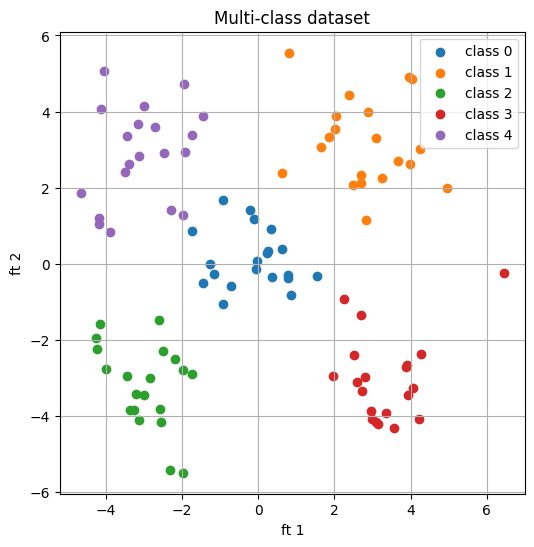

In [65]:
plot_data(x, y)

### OvA implemntation with logitstic regression

#### Model

In [66]:
def sig(z):
    # TODO: clip z
    return 1/(1+np.exp(-z))

In [ ]:
def forward(x, w, b):
    # x:(n,ncls) | w,b:(ncls,)
    z = w @ x + b # (n,)
    